In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"nikenanggraini","key":"908ab96d6b86d1b8e129fd180de374ec"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d atharvasoundankar/smart-farming-sensor-data-for-yield-prediction
!unzip smart-farming-sensor-data-for-yield-prediction.zip

Dataset URL: https://www.kaggle.com/datasets/atharvasoundankar/smart-farming-sensor-data-for-yield-prediction
License(s): apache-2.0
  0% 0.00/27.7k [00:00<?, ?B/s]
100% 27.7k/27.7k [00:00<00:00, 95.5MB/s]
Archive:  smart-farming-sensor-data-for-yield-prediction.zip
  inflating: Smart_Farming_Crop_Yield_2024.csv  


--- Cek missing values ---
farm_id                   0
region                    0
crop_type                 0
soil_moisture_%           0
soil_pH                   0
temperature_C             0
rainfall_mm               0
humidity_%                0
sunlight_hours            0
irrigation_type         150
fertilizer_type           0
pesticide_usage_ml        0
sowing_date               0
harvest_date              0
total_days                0
yield_kg_per_hectare      0
sensor_id                 0
timestamp                 0
latitude                  0
longitude                 0
NDVI_index                0
crop_disease_status     130
dtype: int64


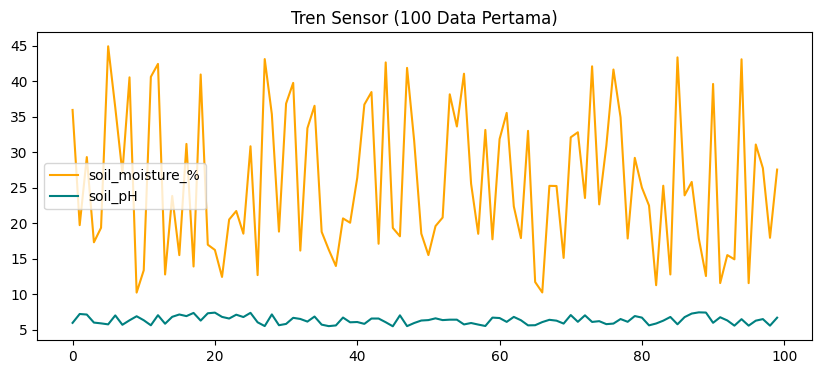

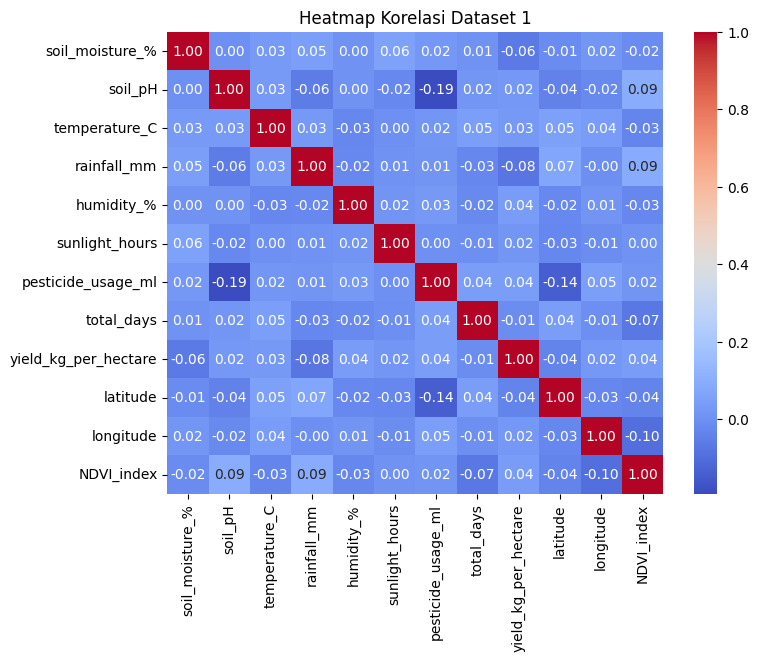


Beres, file cleaned_data.csv untuk Dataset 1 udah disave!


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob

file_csv = glob.glob('*.csv')[0]
df = pd.read_csv(file_csv)

print("--- Cek missing values ---")
print(df.isnull().sum())

kolom_angka = df.select_dtypes(include=['number'])

kolom_1 = kolom_angka.columns[0]
kolom_2 = kolom_angka.columns[1]

plt.figure(figsize=(10,4))
plt.plot(df[kolom_1].head(100), label=kolom_1, color='orange')
plt.plot(df[kolom_2].head(100), label=kolom_2, color='teal')
plt.title('Tren Sensor (100 Data Pertama)')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(kolom_angka.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Dataset 1')
plt.show()

df.to_csv('cleaned_data.csv', index=False)
print("\nBeres, file cleaned_data.csv untuk Dataset 1 udah disave!")